# FinSentinel: Hybrid ML + DL + RL Stock Anomaly Detection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kapurV06/FinSentinel/blob/main/FinSentinel_Colab.ipynb)

---

**FinSentinel** is a three-layer anomaly detection pipeline for equities. An Isolation Forest handles fast unsupervised scoring; an LSTM Autoencoder captures temporal reconstruction error; a DQN agent learns a context-aware alert policy on top of the ensemble. A Claude-powered agentic layer translates scores into analyst-readable reports.

| Layer | Method | Role |
|-------|--------|------|
| ML | Isolation Forest | Unsupervised anomaly scoring |
| DL | LSTM Autoencoder | Temporal reconstruction-error scoring |
| Ensemble | 0.4 IF + 0.6 LSTM | Fused anomaly score |
| RL | DQN (Stable-Baselines3) | Adaptive alert policy |
| Agentic AI | Claude + Tool Use | Autonomous analysis and reporting |

**Problem**: Flash crashes, insider trading signals, earnings shocks, and liquidity crises are hard to catch with static rules. FinSentinel combines three learning paradigms so the alert policy adapts to market context rather than relying on a fixed threshold.

**Evaluation**: 80/20 chronological train/test split. The DQN is trained on 2020-2023 and evaluated on the held-out 2024 period it never saw during weight updates.

**Dataset**: Yahoo Finance — AAPL, TSLA, AMZN, MSFT, GOOGL | 2020-2024
**Runtime**: ~25 min on Colab T4 GPU
**Author**: Varish Kapur | Thapar Institute of Engineering and Technology

In [1]:

!pip install yfinance stable-baselines3[extra] gymnasium anthropic ta plotly -q
!pip install tensorflow -q
!pip install groq
print("done")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.0/932.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 14.4 MB/s eta 0:00:00
done


In [2]:
import groq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
import anthropic
import warnings, json, os
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

TICKERS = ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOGL','NVDA', 'AMD','JPM', 'GS', 'JNJ', 'PFE','XOM', 'CVX','NFLX', 'DIS']
START_DATE    = '2020-01-01'
TRAIN_END     = '2023-12-31'
TEST_START    = '2024-01-01'
END_DATE      = '2024-12-31'
SEQUENCE_LEN  = 20
CONTAMINATION = 0.05
ENSEMBLE_W_IF = 0.40
ENSEMBLE_W_DL = 0.60
RL_TIMESTEPS  = 150_000
ALERT_THRESH  = 0.95


GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

np.random.seed(42)
tf.random.set_seed(42)

print("Imports complete")
print(f"  TensorFlow : {tf.__version__}")
print(f"  Tickers    : {TICKERS}")
print(f"  Train      : {START_DATE} to {TRAIN_END}")
print(f"  Test       : {TEST_START} to {END_DATE}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Imports complete
  TensorFlow : 2.19.0
  Tickers    : ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOGL', 'NVDA', 'AMD', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'NFLX', 'DIS']
  Train      : 2020-01-01 to 2023-12-31
  Test       : 2024-01-01 to 2024-12-31


## Section 3: Data Pipeline

In [3]:
def download_stock_data(tickers, start, end):
    """Download OHLCV data from Yahoo Finance for multiple tickers."""
    data = {}
    for ticker in tickers:
        df = yf.download(ticker, start=start, end=end,
                         progress=False, auto_adjust=True)
        df.dropna(inplace=True)
        # Flatten multi-level columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        data[ticker] = df
        print(f"   {ticker}: {len(df):,} trading days from  "
              f"{df.index[0].date()} to {df.index[-1].date()}")
    return data


stock_data = download_stock_data(TICKERS, START_DATE, END_DATE)
print(f"\ndatasets: {len(stock_data)}")


   AAPL: 1,257 trading days from  2020-01-02 to 2024-12-30
   TSLA: 1,257 trading days from  2020-01-02 to 2024-12-30
   AMZN: 1,257 trading days from  2020-01-02 to 2024-12-30
   MSFT: 1,257 trading days from  2020-01-02 to 2024-12-30
   GOOGL: 1,257 trading days from  2020-01-02 to 2024-12-30
   NVDA: 1,257 trading days from  2020-01-02 to 2024-12-30
   AMD: 1,257 trading days from  2020-01-02 to 2024-12-30
   JPM: 1,257 trading days from  2020-01-02 to 2024-12-30
   GS: 1,257 trading days from  2020-01-02 to 2024-12-30
   JNJ: 1,257 trading days from  2020-01-02 to 2024-12-30
   PFE: 1,257 trading days from  2020-01-02 to 2024-12-30
   XOM: 1,257 trading days from  2020-01-02 to 2024-12-30
   CVX: 1,257 trading days from  2020-01-02 to 2024-12-30
   NFLX: 1,257 trading days from  2020-01-02 to 2024-12-30
   DIS: 1,257 trading days from  2020-01-02 to 2024-12-30

datasets: 15


In [4]:
def compute_features(df):
    """
    Compute 16 technical features optimised for anomaly detection.

    Features:
      Price:   log_returns, volatility_5d, volatility_20d, vol_ratio, z_vs_ma20,
               z_vs_ma50, hl_range, hl_ratio, gap
      Volume:  volume_ratio, volume_z
      Momentum: RSI-normalized, MACD-normalized, BB-position
      Trend:   close_above_ma50 (binary)
    """
    f = pd.DataFrame(index=df.index)

    close = df['Close']
    vol   = df['Volume']

    # price

    f['log_returns']   = np.log(close / close.shift(1))
    f['volatility_5']  = f['log_returns'].rolling(5).std()
    f['volatility_20'] = f['log_returns'].rolling(20).std()
    f['vol_ratio']     = f['volatility_5'] / (f['volatility_20'] + 1e-9)

    ma20 = close.rolling(20).mean(); std20 = close.rolling(20).std()
    ma50 = close.rolling(50).mean(); std50 = close.rolling(50).std()
    f['z_vs_ma20'] = (close - ma20) / (std20 + 1e-9)
    f['z_vs_ma50'] = (close - ma50) / (std50 + 1e-9)

    f['hl_range'] = (df['High'] - df['Low']) / (close + 1e-9)
    hl_ma = f['hl_range'].rolling(10).mean()
    f['hl_ratio'] = f['hl_range'] / (hl_ma + 1e-9)
    f['gap']      = (df['Open'] - close.shift(1)) / (close.shift(1) + 1e-9)

    # volume

    vol_ma = vol.rolling(20).mean()
    f['volume_ratio'] = vol / (vol_ma + 1e-9)
    f['volume_z']     = (vol - vol_ma) / (vol.rolling(20).std() + 1e-9)


    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rsi   = 100 - (100 / (1 + gain / (loss + 1e-9)))
    f['rsi_norm']  = (rsi - 50) / 50          # scale to [-1, 1]

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    f['macd_norm'] = (ema12 - ema26) / (close + 1e-9)

    f['bb_pos'] = (close - ma20) / (2 * std20 + 1e-9)

   # trend
    f['above_ma50'] = (close > ma50).astype(float)

    f.dropna(inplace=True)
    return f

feature_data = {}
for ticker in TICKERS:
    feature_data[ticker] = compute_features(stock_data[ticker])
    print(f"  {ticker}: {feature_data[ticker].shape[1]} features and  "
          f"{len(feature_data[ticker])} samples")

FEATURE_NAMES = list(feature_data[TICKERS[0]].columns)
print(f"\n Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")


  AAPL: 15 features and  1208 samples
  TSLA: 15 features and  1208 samples
  AMZN: 15 features and  1208 samples
  MSFT: 15 features and  1208 samples
  GOOGL: 15 features and  1208 samples
  NVDA: 15 features and  1208 samples
  AMD: 15 features and  1208 samples
  JPM: 15 features and  1208 samples
  GS: 15 features and  1208 samples
  JNJ: 15 features and  1208 samples
  PFE: 15 features and  1208 samples
  XOM: 15 features and  1208 samples
  CVX: 15 features and  1208 samples
  NFLX: 15 features and  1208 samples
  DIS: 15 features and  1208 samples

 Features (15): ['log_returns', 'volatility_5', 'volatility_20', 'vol_ratio', 'z_vs_ma20', 'z_vs_ma50', 'hl_range', 'hl_ratio', 'gap', 'volume_ratio', 'volume_z', 'rsi_norm', 'macd_norm', 'bb_pos', 'above_ma50']


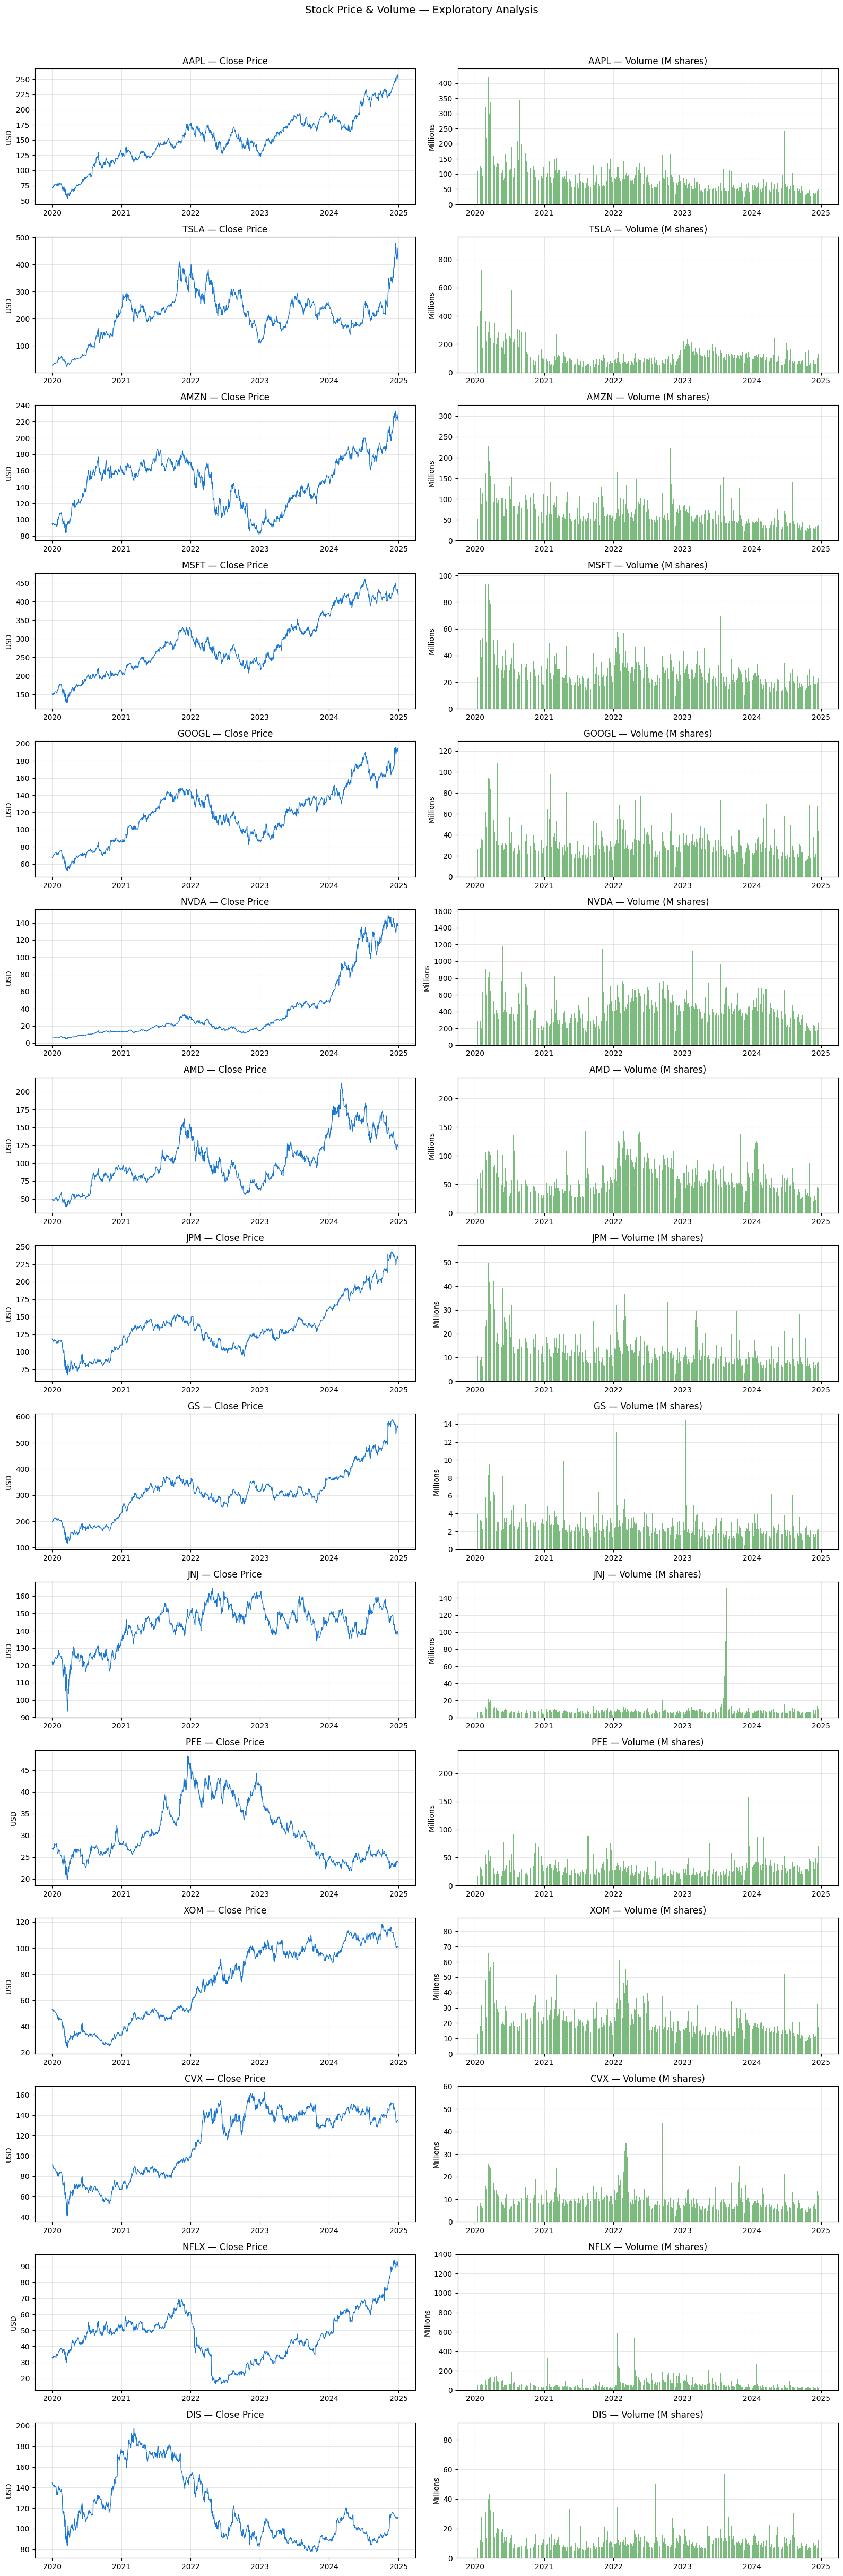

chart saved 


In [5]:
# eda
fig, axes = plt.subplots(len(TICKERS), 2, figsize=(16, 3.2 * len(TICKERS)))
fig.suptitle('Stock Price & Volume — Exploratory Analysis', fontsize=14, y=1.01)

for i, ticker in enumerate(TICKERS):
    df = stock_data[ticker]
    ax1, ax2 = axes[i]

    ax1.plot(df.index, df['Close'], linewidth=1.0, color='#1976D2')
    ax1.set_title(f'{ticker} — Close Price')
    ax1.set_ylabel('USD')
    ax1.grid(alpha=0.3)

    ax2.bar(df.index, df['Volume'] / 1e6, width=1, color='#43A047', alpha=0.7)
    ax2.set_title(f'{ticker} — Volume (M shares)')
    ax2.set_ylabel('Millions')
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("chart saved ")


## Section 4: ML Layer — Isolation Forest

In [6]:
class IFDetector:
    """
    Isolation Forest wrapper with:
      - StandardScaler normalisation
      - Calibrated anomaly score in [0, 1] (higher = more anomalous)
      - Binary label output
    """
    def __init__(self, contamination=CONTAMINATION, n_estimators=200):
        self.scaler = StandardScaler()
        self.model  = IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )

    def fit(self, df: pd.DataFrame):
        X = self.scaler.fit_transform(df)
        self.model.fit(X)
        return self

    def score(self, df: pd.DataFrame) -> tuple:
        """Returns (anomaly_score_0_to_1, binary_labels)."""
        X    = self.scaler.transform(df)
        raw  = self.model.score_samples(X)
        norm = 1 - (raw - raw.min()) / ((raw.max() - raw.min()) + 1e-9)
        labs = (self.model.predict(X) == -1).astype(int)
        return norm, labs

if_detectors, if_scores, if_labels = {}, {}, {}

print("Isolation Forest detectors.")
for ticker in TICKERS:
    feat = feature_data[ticker]
    det  = IFDetector()
    det.fit(feat)
    scores, labels = det.score(feat)

    if_detectors[ticker] = det
    if_scores[ticker]    = scores
    if_labels[ticker]    = labels

    pct = labels.mean() * 100
    print(f"  {ticker}: {labels.sum()} anomalies detected ({pct:.1f}%)")

print("\ntraining complete")


Isolation Forest detectors.
  AAPL: 61 anomalies detected (5.0%)
  TSLA: 61 anomalies detected (5.0%)
  AMZN: 61 anomalies detected (5.0%)
  MSFT: 61 anomalies detected (5.0%)
  GOOGL: 61 anomalies detected (5.0%)
  NVDA: 61 anomalies detected (5.0%)
  AMD: 61 anomalies detected (5.0%)
  JPM: 61 anomalies detected (5.0%)
  GS: 61 anomalies detected (5.0%)
  JNJ: 61 anomalies detected (5.0%)
  PFE: 61 anomalies detected (5.0%)
  XOM: 61 anomalies detected (5.0%)
  CVX: 61 anomalies detected (5.0%)
  NFLX: 61 anomalies detected (5.0%)
  DIS: 61 anomalies detected (5.0%)

training complete


## Section 5: DL Layer — LSTM Autoencoder

In [7]:
def build_lstm_ae(n_features: int, seq_len: int, latent_dim: int = 32):
    """
    Stacked LSTM Autoencoder.
    Encoder: LSTM(64) → LSTM(latent_dim)
    Decoder: RepeatVector → LSTM(latent_dim) → LSTM(64) → TimeDistributed(Dense)
    Loss  : MSE (reconstruction error)
    """
    inp = keras.Input(shape=(seq_len, n_features), name='input')

    # encoder
    x = layers.LSTM(64, return_sequences=True, name='enc1')(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(latent_dim, return_sequences=False, name='enc2')(x)

    # bottleneck
    x = layers.RepeatVector(seq_len, name='bottleneck')(x)
    x = layers.LSTM(latent_dim, return_sequences=True, name='dec1')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64, return_sequences=True, name='dec2')(x)
    out = layers.TimeDistributed(layers.Dense(n_features), name='output')(x)

    model = keras.Model(inp, out, name='LSTM_Autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return model


def make_sequences(arr: np.ndarray, seq_len: int) -> np.ndarray:
    return np.array([arr[i:i + seq_len] for i in range(len(arr) - seq_len)])


def reconstruction_score(model, X_seq: np.ndarray) -> np.ndarray:
    """Per-sample MSE normalised to [0, 1]."""
    X_pred = model.predict(X_seq, verbose=0)
    mse    = np.mean((X_seq - X_pred) ** 2, axis=(1, 2))
    return (mse - mse.min()) / ((mse.max() - mse.min()) + 1e-9)


lstm_models, lstm_scores = {}, {}

n_feat = len(FEATURE_NAMES)
print(f" Building LSTM Autoencoders with seq_len={SEQUENCE_LEN}  n_features={n_feat}\n")

for ticker in TICKERS:
    print(f"  {ticker}  training")

    feat   = feature_data[ticker]
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(feat)
    X_seq  = make_sequences(X_sc, SEQUENCE_LEN)

    # 80/20 split — train only on 'normal' history
    split    = int(0.8 * len(X_seq))
    X_train  = X_seq[:split]

    model = build_lstm_ae(n_feat, SEQUENCE_LEN)
    cb = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
    ]
    hist = model.fit(
        X_train, X_train,
        epochs=50, batch_size=32,
        validation_split=0.1,
        callbacks=cb, verbose=0
    )

    scores = reconstruction_score(model, X_seq)
    lstm_models[ticker] = {'model': model, 'scaler': scaler}
    lstm_scores[ticker] = scores

    best_loss = min(hist.history['val_loss'])
    print(f"   val_loss={best_loss:.5f} scoring {len(scores)} windows")

print("\n LSTM training complete")


 Building LSTM Autoencoders with seq_len=20  n_features=15

  AAPL  training
   val_loss=0.41998 scoring 1188 windows
  TSLA  training
   val_loss=0.39278 scoring 1188 windows
  AMZN  training
   val_loss=0.41094 scoring 1188 windows
  MSFT  training
   val_loss=0.41795 scoring 1188 windows
  GOOGL  training
   val_loss=0.50706 scoring 1188 windows
  NVDA  training
   val_loss=0.39619 scoring 1188 windows
  AMD  training
   val_loss=0.45739 scoring 1188 windows
  JPM  training
   val_loss=0.40530 scoring 1188 windows
  GS  training
   val_loss=0.41987 scoring 1188 windows
  JNJ  training
   val_loss=0.47295 scoring 1188 windows
  PFE  training
   val_loss=0.59513 scoring 1188 windows
  XOM  training
   val_loss=0.41919 scoring 1188 windows
  CVX  training
   val_loss=0.44980 scoring 1188 windows
  NFLX  training
   val_loss=0.44516 scoring 1188 windows
  DIS  training
   val_loss=0.40514 scoring 1188 windows

 LSTM training complete


## Section 6: Ensemble Anomaly Score

In [8]:
def build_ensemble(ticker: str) -> pd.Series:
    """
    Weighted ensemble: score = 0.4·IF + 0.6·LSTM
    Returns a pd.Series indexed by date.
    """
    if_sc   = if_scores[ticker][SEQUENCE_LEN:]     # align with LSTM output length
    lstm_sc = lstm_scores[ticker]

    min_len = min(len(if_sc), len(lstm_sc))
    if_sc   = if_sc[-min_len:]
    lstm_sc = lstm_sc[-min_len:]

    ensemble = ENSEMBLE_W_IF * if_sc + ENSEMBLE_W_DL * lstm_sc

    # Attach dates — align from the end of feature_data
    dates = feature_data[ticker].index[SEQUENCE_LEN:][-min_len:]
    return pd.Series(ensemble, index=dates, name='anomaly_score')

ensemble_scores = {}
print(" Building ensemble anomaly scores...")
for ticker in TICKERS:
    s   = build_ensemble(ticker)
    thr = s.quantile(ALERT_THRESH)
    n   = (s > thr).sum()
    ensemble_scores[ticker] = s
    print(f"  {ticker}: threshold={thr:.4f} and the {n} events above {int(ALERT_THRESH*100)}th pct")

print("\n Ensemble scoring complete")


 Building ensemble anomaly scores...
  AAPL: threshold=0.3288 and the 60 events above 95th pct
  TSLA: threshold=0.4269 and the 60 events above 95th pct
  AMZN: threshold=0.5141 and the 60 events above 95th pct
  MSFT: threshold=0.2536 and the 60 events above 95th pct
  GOOGL: threshold=0.4295 and the 60 events above 95th pct
  NVDA: threshold=0.4798 and the 60 events above 95th pct
  AMD: threshold=0.4494 and the 60 events above 95th pct
  JPM: threshold=0.2724 and the 60 events above 95th pct
  GS: threshold=0.2658 and the 60 events above 95th pct
  JNJ: threshold=0.2346 and the 60 events above 95th pct
  PFE: threshold=0.3874 and the 60 events above 95th pct
  XOM: threshold=0.3252 and the 60 events above 95th pct
  CVX: threshold=0.2379 and the 60 events above 95th pct
  NFLX: threshold=0.2548 and the 60 events above 95th pct
  DIS: threshold=0.3724 and the 60 events above 95th pct

 Ensemble scoring complete


In [9]:
def plot_anomaly_dashboard(ticker: str):
    """Interactive Plotly dashboard: price + anomaly score + volume."""
    scores = ensemble_scores[ticker]
    price  = stock_data[ticker]['Close']
    feat   = feature_data[ticker]

    idx    = scores.index.intersection(price.index)
    scores = scores[idx]; price = price[idx]
    thr    = scores.quantile(ALERT_THRESH)
    anom   = scores > thr

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        subplot_titles=[
            f'{ticker} — Price & Anomaly Events',
            'Ensemble Anomaly Score',
            'Volume Ratio'
        ],
        row_heights=[0.50, 0.30, 0.20],
        vertical_spacing=0.06
    )

    # Price
    fig.add_trace(go.Scatter(
        x=price.index, y=price, name='Close',
        line=dict(color='#42A5F5', width=1.5)
    ), row=1, col=1)

    # Anomaly markers
    fig.add_trace(go.Scatter(
        x=price[anom].index, y=price[anom],
        mode='markers', name='Anomaly',
        marker=dict(color='#EF5350', size=9, symbol='triangle-up',
                    line=dict(color='white', width=0.5))
    ), row=1, col=1)

    # Score band
    fig.add_trace(go.Scatter(
        x=scores.index, y=scores,
        name='Anomaly Score',
        line=dict(color='#FFA726', width=1),
        fill='tozeroy', fillcolor='rgba(255,167,38,0.12)'
    ), row=2, col=1)
    fig.add_hline(
        y=thr, line_dash='dash', line_color='red',
        annotation_text=f'{int(ALERT_THRESH*100)}th pct',
        annotation_position='top right', row=2, col=1
    )

    # Volume ratio
    vol_idx = feat['volume_ratio'].index.intersection(idx)
    fig.add_trace(go.Bar(
        x=vol_idx, y=feat['volume_ratio'][vol_idx],
        name='Volume Ratio', marker_color='#66BB6A', opacity=0.75
    ), row=3, col=1)

    fig.update_layout(
        title=dict(text=f'FinSentinel Dashboard — {ticker}', font_size=16),
        height=820, template='plotly_dark', hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    fig.show()


for ticker in TICKERS:
    plot_anomaly_dashboard(ticker)


## Section 7: RL Layer — DQN Alert Policy

In [10]:
class StockAlertEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, ticker: str = 'AAPL', sig_move: float = 0.02,
                 split: str = 'train'):
        super().__init__()
        self.ticker   = ticker
        self.sig_move = sig_move
        self.split    = split
        self.consecutive_alerts = 0
        self._build_states()

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def _build_states(self):
        scores = ensemble_scores[self.ticker]
        price  = stock_data[self.ticker]['Close']
        feat   = feature_data[self.ticker]

        idx = scores.index.intersection(price.index).intersection(feat.index)

        if self.split == 'train':
            idx = idx[idx <= TRAIN_END]
        else:
            idx = idx[idx >= TEST_START]

        scores = scores[idx]; price = price[idx]; feat = feat.loc[idx]
        fwd_ret = price.pct_change(5).shift(-5)

        states, sig = [], []
        for i in range(len(idx) - 5):
            global_i = feature_data[self.ticker].index.get_loc(idx[i])
            s = [
                float(scores.iloc[i]),
                float(if_scores[self.ticker][global_i])
                    if global_i < len(if_scores[self.ticker]) else 0.5,
                float(lstm_scores[self.ticker][i])
                    if i < len(lstm_scores[self.ticker]) else 0.5,
                float(feat['log_returns'].iloc[i]),
                float(feat['volume_ratio'].iloc[i]),
                float(feat['rsi_norm'].iloc[i])
            ]
            states.append(s)
            ticker_vol = feat['volatility_20'].iloc[i]
            dynamic_threshold = max(self.sig_move, ticker_vol * 1.5)
            sig.append(abs(fwd_ret.iloc[i]) > dynamic_threshold)

        self.states       = np.array(states, dtype=np.float32)
        self.sig          = np.array(sig)
        self.states_index = idx[:-5].tolist()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_idx = 0
        self.consecutive_alerts = 0
        self.tp = self.fp = self.fn = self.tn = 0
        return self.states[0], {}

    def step(self, action):
        is_sig = self.sig[self.step_idx]

        alert_rate_so_far  = (self.tp + self.fp) / max(self.step_idx, 1)
        alert_rate_penalty = max(0, alert_rate_so_far - 0.70) * 5.0

        if action == 1:
            if is_sig:
                reward = 2.0
                self.tp += 1
            else:
                reward = -2.5 - alert_rate_penalty
                if self.consecutive_alerts > 2:
                    reward -= 1.0
                self.fp += 1
            self.consecutive_alerts += 1
        else:
            reward = -1.0 if is_sig else 0.1
            if is_sig: self.fn += 1
            else:      self.tn += 1
            self.consecutive_alerts = 0

        self.step_idx += 1
        done     = self.step_idx >= len(self.states) - 1
        next_obs = self.states[min(self.step_idx, len(self.states) - 1)]

        prec = self.tp / max(self.tp + self.fp, 1)
        rec  = self.tp / max(self.tp + self.fn, 1)
        info = {'precision': prec, 'recall': rec}

        return next_obs, reward, done, False, info

    def render(self): pass

check_env(StockAlertEnv('AAPL', split='train'), warn=True)
print("Environment check passed")


Environment check passed


In [11]:
rl_agents = {}

print(f"Training DQN agents on train split ({RL_TIMESTEPS:,} steps each)...")
print(f"  Period: {START_DATE} to {TRAIN_END}\n")

for ticker in TICKERS:
    env = StockAlertEnv(ticker=ticker, split='train')
    agent = DQN(
        policy='MlpPolicy',
        env=env,
        learning_rate=5e-5,
        buffer_size=50_000,
        batch_size=128,
        gamma=0.97,
        exploration_fraction=0.40,
        exploration_final_eps=0.02,
        target_update_interval=1000,
        policy_kwargs=dict(net_arch=[256, 256, 128]),
        verbose=0
)
    agent.learn(total_timesteps=RL_TIMESTEPS, progress_bar=False)
    rl_agents[ticker] = agent
    print(f"  {ticker} trained")

print("\nAll DQN agents trained")

Training DQN agents on train split (150,000 steps each)...
  Period: 2020-01-01 to 2023-12-31

  AAPL trained
  TSLA trained
  AMZN trained
  MSFT trained
  GOOGL trained
  NVDA trained
  AMD trained
  JPM trained
  GS trained
  JNJ trained
  PFE trained
  XOM trained
  CVX trained
  NFLX trained
  DIS trained

All DQN agents trained


Evaluating on test split (2024-01-01 to 2024-12-31)

        total_alerts  precision  recall  f1_score  alert_rate
ticker                                                       
AAPL             150      0.480   0.615     0.539        61.2
TSLA              65      0.508   0.295     0.373        26.5
AMZN             116      0.405   0.398     0.402        47.3
MSFT             107      0.542   0.460     0.498        43.7
GOOGL            132      0.477   0.508     0.492        53.9
NVDA             125      0.528   0.496     0.512        51.0
AMD               77      0.558   0.361     0.439        31.4
JPM               57      0.421   0.233     0.300        23.3
GS               118      0.415   0.480     0.445        48.2
JNJ               43      0.279   0.141     0.188        17.6
PFE              127      0.394   0.442     0.417        51.8
XOM               81      0.407   0.250     0.310        33.1
CVX               88      0.466   0.347     0.398        35.9
NFLX             

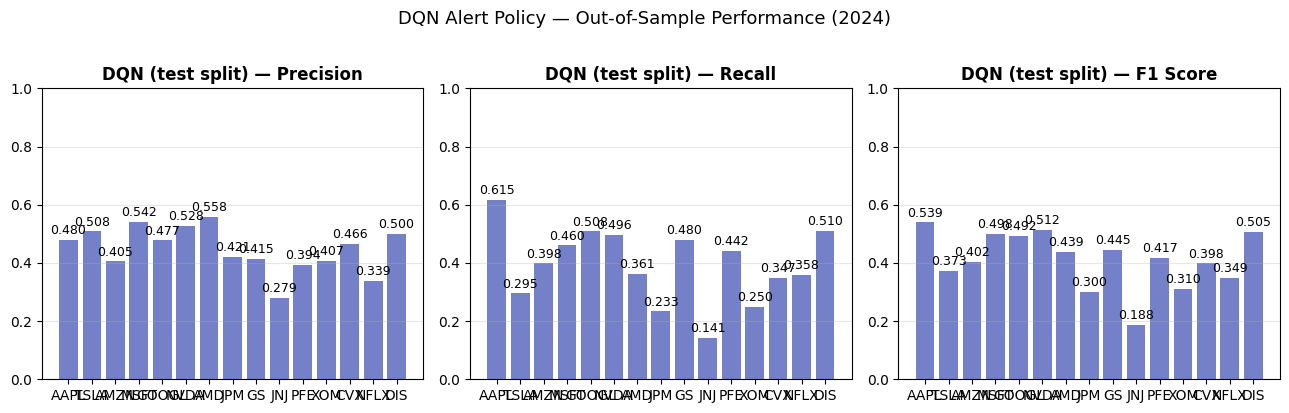

In [16]:
def evaluate_rl_agent(ticker: str) -> dict:
    """
    Run the trained agent on the held-out test split (2024).
    Agent weights are frozen — predict only, no further learning.
    """
    env    = StockAlertEnv(ticker=ticker, split='test')
    obs, _ = env.reset()
    agent  = rl_agents[ticker]

    alerts, actuals = [], []
    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(action))
        alerts.append(int(action))
        actuals.append(1 if env.sig[env.step_idx - 1] else 0)

    arr_a = np.array(alerts); arr_t = np.array(actuals)
    tp  = ((arr_a == 1) & (arr_t == 1)).sum()
    fp  = ((arr_a == 1) & (arr_t == 0)).sum()
    fn  = ((arr_a == 0) & (arr_t == 1)).sum()
    prec  = tp / max(tp + fp, 1)
    rec   = tp / max(tp + fn, 1)
    f1    = 2 * prec * rec / max(prec + rec, 1e-9)

    return {
        'ticker':       ticker,
        'total_alerts': int(arr_a.sum()),
        'precision':    round(prec, 3),
        'recall':       round(rec,  3),
        'f1_score':     round(f1,   3),
        'alert_rate':   round(arr_a.mean() * 100, 1)
    }

print(f"Evaluating on test split ({TEST_START} to {END_DATE})\n")
results = [evaluate_rl_agent(t) for t in TICKERS]
df_res  = pd.DataFrame(results).set_index('ticker')
print(df_res.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['precision', 'recall', 'f1_score']):
    bars = ax.bar(df_res.index, df_res[metric], color='#5C6BC0', alpha=0.85)
    ax.set_title(f'DQN (test split) — {metric.replace("_", " ").title()}',
                 fontweight='bold')
    ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_res[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('DQN Alert Policy — Out-of-Sample Performance (2024)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('rl_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/FinSentinel/'
import os
os.makedirs(BASE + 'models', exist_ok=True)

for ticker in TICKERS:
    rl_agents[ticker].save(BASE + f'models/dqn_{ticker}')
print("all models saved to Drive")


Mounted at /content/drive
all models saved to Drive


In [ ]:
# Save all computed artifacts to Drive for Notebook 2
import pickle, os

artifacts = {
    'stock_data':       {t: stock_data[t] for t in TICKERS},
    'feature_data':     feature_data,
    'if_scores':        if_scores,
    'if_labels':        if_labels,
    'lstm_scores':      lstm_scores,
    'ensemble_scores':  ensemble_scores,
}

os.makedirs(BASE + 'artifacts', exist_ok=True)
with open(BASE + 'artifacts/pipeline_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("artifacts saved to Drive")
print("Notebook 1 complete — open Notebook 2 for evaluation")
